https://chatgpt.com/share/6ac3991c-7680-83e9-b2aa-f8b514f1ec60


# **Step 1 Problem statement**

### Problem Statement: 2026 eThekwini Metro Election Analytics and Governance Risk Forecasting

Political fragmentation, changing voter turnout patterns, and shifting ward dynamics present major challenges for municipal governance planning in South Africa. As the country approaches the 04 November 2026 Local Government Elections, metropolitan municipalities like **eThekwini (ETH)** face increasing uncertainty regarding council seat distribution, party vote shares, and potential coalition requirements. Traditional polling and opinion-based predictions often lack granular, ward-level technical justification and may fail to account for spatial and temporal boundary variations across election cycles.### Problem Statement: 2026 eThekwini Metro Election Analytics and Governance Risk Forecasting

Political fragmentation, changing voter turnout patterns, and shifting ward dynamics present major challenges for municipal governance planning in South Africa. As the country approaches the **04 November 2026 Local Government Elections**, metropolitan municipalities like **eThekwini (ETH)** face increasing uncertainty regarding council seat distribution, party vote shares, and potential coalition requirements. Traditional polling and opinion-based predictions often lack granular, ward-level technical justification and may fail to account for spatial and temporal variations across election cycles.

To address these challenges using empirical evidence, the **National.csv** dataset provides a traceable, open-data foundation for the analysis. The dataset contains historical municipal election records and includes relevant variables such as `RegisteredVoters`, `TotalValidVotes`, `PartyName`, and `BallotType`. The dataset was selected because its election-level and ward-level information can be filtered specifically for **eThekwini Municipality (ETH)** and used as historical evidence for forecasting the 2026 election. The underlying historical election data is available through the **Electoral Commission of South Africa (IEC) Data Downloads portal**: https://results.elections.org.za/home/Downloads/ME-Results/.

Importantly, the dataset used for this project was **identified as the relevant election dataset for the selected study area, eThekwini Municipality**, rather than using an unrelated general election dataset. The historical records provide the date/election context and voting information needed to establish patterns over previous election cycles. However, because the **04 November 2026 election is a future election**, the dataset does not contain the actual 2026 election results; instead, the historical records are used to train and evaluate the forecasting models that will estimate likely 2026 outcomes.

Therefore, this study aims to develop a machine learning forecasting workflow and an interactive Streamlit dashboard to estimate **party vote shares, overall voter turnout rates, and leading political parties across selected target wards in eThekwini Municipality for the 04 November 2026 elections**. The system will use historical election patterns as the basis for generating data-driven forecasts rather than presenting the predictions as confirmed election results.


To address these challenges using empirical evidence, historical municipal election data structured in the `National.csv` dataset provides a traceable, open-data foundation. This dataset captures critical voting district and ward-level indicators, including registered voter counts (`RegisteredVoters`), total valid votes (`TotalValidVotes`), party names (`PartyName`), and ballot types (`BallotType`). All underlying historical election datasets are publicly available from the Electoral Commission of South Africa (IEC) Data Downloads portal: https://results.elections.org.za/home/Downloads/ME-Results/.

Therefore, this study aims to develop a machine learning forecasting workflow and an interactive Streamlit dashboard to estimate party vote shares, overall voter turnout rates, and leading political parties across selected target wards in eThekwini Municipality for the 04 November 2026 elections.

The proposed system seeks to deliver a technically defensible, reproducible analytics solution that allows researchers and governance analysts to trace the full pipeline—from data acquisition and boundary alignment to model evaluation and uncertainty estimation—without introducing political bias. The forecasts will be presented as data-driven estimates rather than guaranteed election outcomes.


# **Step 2  Data understanding **

In [11]:
# import pandas library for loading and maniplulation
import pandas as pd

In [12]:
#load the raw dataset 
df=pd.read_csv('National.csv')


In [13]:
#reviwe the first 10 rows
df.head(10)

,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,AFRICAN CHRISTIAN DEMOCRATIC PARTY,3,2/16/2017 5:01:24 PM
1,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,AFRICAN INDEPENDENT CONGRESS,19,2/16/2017 5:01:24 PM
2,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,AFRICAN NATIONAL CONGRESS,347,2/16/2017 5:01:24 PM
3,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,CONGRESS OF THE PEOPLE,7,2/16/2017 5:01:24 PM
4,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,DEMOCRATIC ALLIANCE,751,2/16/2017 5:01:24 PM
5,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,ECONOMIC FREEDOM FIGHTERS,18,2/16/2017 5:01:24 PM
6,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,PAN AFRICANIST CONGRESS OF AZANIA,1,2/16/2017 5:01:24 PM
7,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,PAN AFRICANIST MOVEMENT,0,2/16/2017 5:01:24 PM
8,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,PEOPLES ALLIANCE,0,2/16/2017 5:01:24 PM
9,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,UNITED CONGRESS,0,2/16/2017 5:01:24 PM


In [14]:
# Check column names, data types, and non-null counts

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 653063 entries, 0 to 653062
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Province           653063 non-null  str  
 1   Municipality       653063 non-null  str  
 2   Ward               653063 non-null  str  
 3   VotingDistrict     653063 non-null  int64
 4   VotingStationName  653063 non-null  str  
 5   RegisteredVoters   653063 non-null  int64
 6   BallotType         653063 non-null  str  
 7   SpoiltVotes        653063 non-null  int64
 8   PartyName          653063 non-null  str  
 9   TotalValidVotes    653063 non-null  int64
 10  DateGenerated      653063 non-null  str  
dtypes: int64(4), str(7)
memory usage: 127.3 MB


In [15]:
# Check for duplicate
df.duplicated().sum()

np.int64(0)

In [16]:
# Summary statistics (mean, std, min, max, quartiles) for all numeric columns
df.describe()


,VotingDistrict,RegisteredVoters,SpoiltVotes,TotalValidVotes
count,6.530630e+05,653063.000000,653063.000000,653063.000000
mean,5.210910e+07,1321.375292,13.523300,58.980501
std,2.864130e+07,1095.583366,22.960789,194.378248
min,1.002001e+07,6.000000,0.000000,0.000000
25%,3.286210e+07,488.000000,3.000000,0.000000
50%,4.374030e+07,979.000000,8.000000,2.000000
75%,7.634026e+07,1905.000000,16.000000,18.000000
max,9.843027e+07,9891.000000,993.000000,5012.000000


In [18]:
# Check number of rows and columns in the dataset
df.shape

(653063, 11)

In [19]:
#check if there is missing value 
df.isnull().sum()

Province             0
Municipality         0
Ward                 0
VotingDistrict       0
VotingStationName    0
RegisteredVoters     0
BallotType           0
SpoiltVotes          0
PartyName            0
TotalValidVotes      0
DateGenerated        0
dtype: int64

## Stage 2: Cleaning & Preparation

In [23]:
print(df.columns.tolist())

['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']


In [24]:
df


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,AFRICAN CHRISTIAN DEMOCRATIC PARTY,3,2/16/2017 5:01:24 PM
1,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,AFRICAN INDEPENDENT CONGRESS,19,2/16/2017 5:01:24 PM
2,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,AFRICAN NATIONAL CONGRESS,347,2/16/2017 5:01:24 PM
3,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,CONGRESS OF THE PEOPLE,7,2/16/2017 5:01:24 PM
4,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230,PR,21,DEMOCRATIC ALLIANCE,751,2/16/2017 5:01:24 PM
...,...,...,...,...,...,...,...,...,...,...,...
653058,Western Cape,WC053 - Beaufort West,Ward 10503007,98180040,TWEERIVIERE FARM HOUSE,154,Ward,2,INDEPENDENT CIVIC ORGANISATION OF SOUTH AFRICA,0,2/16/2017 5:01:24 PM
653059,Western Cape,WC053 - Beaufort West,Ward 10503007,98180040,TWEERIVIERE FARM HOUSE,154,Ward,2,KAROO DEMOCRATIC FORCE,0,2/16/2017 5:01:24 PM
653060,Western Cape,WC053 - Beaufort West,Ward 10503007,98180040,TWEERIVIERE FARM HOUSE,154,Ward,2,PAN AFRICANIST CONGRESS OF AZANIA,0,2/16/2017 5:01:24 PM
653061,Western Cape,WC053 - Beaufort West,Ward 10503007,98180040,TWEERIVIERE FARM HOUSE,154,Ward,2,SOUTH AFRICAN RELIGIOUS CIVIC ORGANISATION,0,2/16/2017 5:01:24 PM


In [25]:
# Convert the 'Generated date' column to datetime format
df['DateGenerated'] = pd.to_datetime(df['DateGenerated'])


df.info()

<class 'pandas.DataFrame'>
RangeIndex: 653063 entries, 0 to 653062
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Province           653063 non-null  str           
 1   Municipality       653063 non-null  str           
 2   Ward               653063 non-null  str           
 3   VotingDistrict     653063 non-null  int64         
 4   VotingStationName  653063 non-null  str           
 5   RegisteredVoters   653063 non-null  int64         
 6   BallotType         653063 non-null  str           
 7   SpoiltVotes        653063 non-null  int64         
 8   PartyName          653063 non-null  str           
 9   TotalValidVotes    653063 non-null  int64         
 10  DateGenerated      653063 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(4), str(6)
memory usage: 114.9 MB


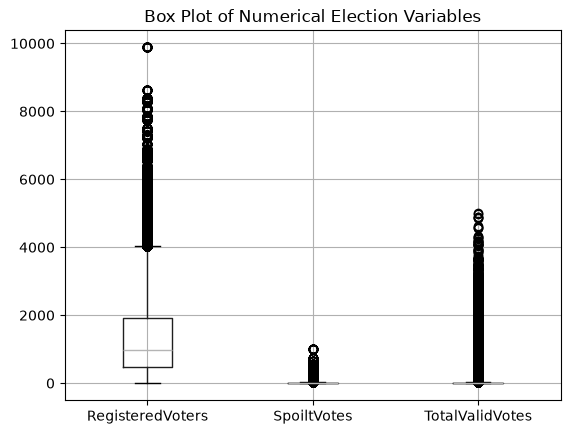

In [29]:
df[['RegisteredVoters', 'SpoiltVotes', 'TotalValidVotes']].boxplot()
plt.title('Box Plot of Numerical Election Variables')
plt.show()

In [31]:
# Numerical columns only
numerical_columns = [
    'RegisteredVoters',
    'SpoiltVotes',
    'TotalValidVotes'
]

# Count outliers using the 1.5 × IQR rule
for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f'{column}: {len(outliers)} outliers')

RegisteredVoters: 17323 outliers
SpoiltVotes: 48138 outliers
TotalValidVotes: 117617 outliers


2017-02-16 17:01:24
2017-02-16 17:01:24


In [37]:
    # Cap values 
numerical_columns = [
    'RegisteredVoters',
    'SpoiltVotes',
    'TotalValidVotes'
]

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1
    # Cap values outside upper/lower bounds

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the outliers
    df[column] = df[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outliers capped successfully.")

Outliers capped successfully.


In [39]:
#now we re-check if there are outerliers
numerical_columns = [
    'RegisteredVoters',
    'SpoiltVotes',
    'TotalValidVotes'
]

# Count outliers using the 1.5 × IQR rule
for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f'{column}: {len(outliers)} outliers')

RegisteredVoters: 0 outliers
SpoiltVotes: 0 outliers
TotalValidVotes: 0 outliers


In [40]:
#the re-check if data is cleaned
df.head(5)

,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230.0,PR,21.0,AFRICAN CHRISTIAN DEMOCRATIC PARTY,3,2017-02-16 17:01:24
1,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230.0,PR,21.0,AFRICAN INDEPENDENT CONGRESS,19,2017-02-16 17:01:24
2,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230.0,PR,21.0,AFRICAN NATIONAL CONGRESS,45,2017-02-16 17:01:24
3,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230.0,PR,21.0,CONGRESS OF THE PEOPLE,7,2017-02-16 17:01:24
4,Eastern Cape,BUF - Buffalo City,Ward 29200001,10590151,PEFFERVILLE CLINIC,2230.0,PR,21.0,DEMOCRATIC ALLIANCE,45,2017-02-16 17:01:24


In [42]:
df['PartyName']

0                     AFRICAN CHRISTIAN DEMOCRATIC PARTY
1                           AFRICAN INDEPENDENT CONGRESS
2                              AFRICAN NATIONAL CONGRESS
3                                CONGRESS  OF THE PEOPLE
4                                    DEMOCRATIC ALLIANCE
                               ...                      
653058    INDEPENDENT CIVIC ORGANISATION OF SOUTH AFRICA
653059                            KAROO DEMOCRATIC FORCE
653060                 PAN AFRICANIST CONGRESS OF AZANIA
653061        SOUTH AFRICAN RELIGIOUS CIVIC ORGANISATION
653062                                VRYHEIDSFRONT PLUS
Name: PartyName, Length: 653063, dtype: str

In [43]:
print("Number of parties:", df['PartyName'].nunique())

print("\nParty distribution:")
print(df['PartyName'].value_counts())

Number of parties: 206

Party distribution:
PartyName
AFRICAN NATIONAL CONGRESS      62925
DEMOCRATIC ALLIANCE            62864
ECONOMIC FREEDOM FIGHTERS      62132
VRYHEIDSFRONT PLUS             37430
CONGRESS  OF THE PEOPLE        36336
                               ...  
GAMAGARA COMMUNITY FORUM          19
KGATELOPELE COMMUNITY FORUM       16
KAROO ONTWIKKELINGS PARTY         14
ZULU ROYAL PROPERTY                7
AFRICAN LIBERATION PARTY           4
Name: count, Length: 206, dtype: int64


In [44]:
print(df[['VotingDistrict', 'PartyName', 'TotalValidVotes']].head(20))

    VotingDistrict                           PartyName  TotalValidVotes
0         10590151  AFRICAN CHRISTIAN DEMOCRATIC PARTY                3
1         10590151        AFRICAN INDEPENDENT CONGRESS               19
2         10590151           AFRICAN NATIONAL CONGRESS               45
3         10590151             CONGRESS  OF THE PEOPLE                7
4         10590151                 DEMOCRATIC ALLIANCE               45
5         10590151           ECONOMIC FREEDOM FIGHTERS               18
6         10590151   PAN AFRICANIST CONGRESS OF AZANIA                1
7         10590151             PAN AFRICANIST MOVEMENT                0
8         10590151                    PEOPLES ALLIANCE                0
9         10590151                     UNITED CONGRESS                0
10        10590151          UNITED DEMOCRATIC MOVEMENT                5
11        10590151    UNITED FRONT OF THE EASTERN CAPE                1
12        10590151  AFRICAN CHRISTIAN DEMOCRATIC PARTY          

In [45]:
party_votes = (
    df.groupby('PartyName')['TotalValidVotes']
      .sum()
      .sort_values(ascending=False)
)

print(party_votes.head(10))

PartyName
AFRICAN NATIONAL CONGRESS             2709729
ECONOMIC FREEDOM FIGHTERS             1506372
DEMOCRATIC ALLIANCE                   1420724
INKATHA FREEDOM PARTY                  491790
AFRICAN INDEPENDENT CONGRESS           304351
VRYHEIDSFRONT PLUS                     196966
UNITED DEMOCRATIC MOVEMENT             173086
CONGRESS  OF THE PEOPLE                151731
AFRICAN CHRISTIAN DEMOCRATIC PARTY     143452
INDEPENDENT                             99987
Name: TotalValidVotes, dtype: int64


In [46]:
# Find the index of the party with the highest votes in each Ward
winning_idx = df.groupby(
    ['Province', 'Municipality', 'Ward']
)['TotalValidVotes'].idxmax()

# Create the WinningParty column
df['WinningParty'] = None

df.loc[winning_idx, 'WinningParty'] = df.loc[
    winning_idx, 'PartyName'
]

# Fill the winning party down to all rows belonging to the same ward
df['WinningParty'] = df.groupby(
    ['Province', 'Municipality', 'Ward']
)['WinningParty'].transform('first')

print(df[
    ['Province', 'Municipality', 'Ward', 'PartyName',
     'TotalValidVotes', 'WinningParty']
].head(20))

        Province        Municipality           Ward  \
0   Eastern Cape  BUF - Buffalo City  Ward 29200001   
1   Eastern Cape  BUF - Buffalo City  Ward 29200001   
2   Eastern Cape  BUF - Buffalo City  Ward 29200001   
3   Eastern Cape  BUF - Buffalo City  Ward 29200001   
4   Eastern Cape  BUF - Buffalo City  Ward 29200001   
5   Eastern Cape  BUF - Buffalo City  Ward 29200001   
6   Eastern Cape  BUF - Buffalo City  Ward 29200001   
7   Eastern Cape  BUF - Buffalo City  Ward 29200001   
8   Eastern Cape  BUF - Buffalo City  Ward 29200001   
9   Eastern Cape  BUF - Buffalo City  Ward 29200001   
10  Eastern Cape  BUF - Buffalo City  Ward 29200001   
11  Eastern Cape  BUF - Buffalo City  Ward 29200001   
12  Eastern Cape  BUF - Buffalo City  Ward 29200001   
13  Eastern Cape  BUF - Buffalo City  Ward 29200001   
14  Eastern Cape  BUF - Buffalo City  Ward 29200001   
15  Eastern Cape  BUF - Buffalo City  Ward 29200001   
16  Eastern Cape  BUF - Buffalo City  Ward 29200001   
17  Easter

In [47]:
# Find the maximum votes in each ward
max_votes = df.groupby(
    ['Province', 'Municipality', 'Ward']
)['TotalValidVotes'].transform('max')

# Count how many parties have the maximum votes in each ward
winner_count = (
    df['TotalValidVotes'].eq(max_votes)
    .groupby([
        df['Province'],
        df['Municipality'],
        df['Ward']
    ])
    .transform('sum')
)

# Check tied wards
tied_rows = df[winner_count > 1]

print("Rows involved in ties:", len(tied_rows))

Rows involved in ties: 653063


In [48]:
print(
    tied_rows[
        ['Province', 'Municipality', 'Ward',
         'PartyName', 'TotalValidVotes']
    ].head(30)
)

        Province        Municipality           Ward  \
0   Eastern Cape  BUF - Buffalo City  Ward 29200001   
1   Eastern Cape  BUF - Buffalo City  Ward 29200001   
2   Eastern Cape  BUF - Buffalo City  Ward 29200001   
3   Eastern Cape  BUF - Buffalo City  Ward 29200001   
4   Eastern Cape  BUF - Buffalo City  Ward 29200001   
5   Eastern Cape  BUF - Buffalo City  Ward 29200001   
6   Eastern Cape  BUF - Buffalo City  Ward 29200001   
7   Eastern Cape  BUF - Buffalo City  Ward 29200001   
8   Eastern Cape  BUF - Buffalo City  Ward 29200001   
9   Eastern Cape  BUF - Buffalo City  Ward 29200001   
10  Eastern Cape  BUF - Buffalo City  Ward 29200001   
11  Eastern Cape  BUF - Buffalo City  Ward 29200001   
12  Eastern Cape  BUF - Buffalo City  Ward 29200001   
13  Eastern Cape  BUF - Buffalo City  Ward 29200001   
14  Eastern Cape  BUF - Buffalo City  Ward 29200001   
15  Eastern Cape  BUF - Buffalo City  Ward 29200001   
16  Eastern Cape  BUF - Buffalo City  Ward 29200001   
17  Easter

In [49]:
ward_party_votes = (
    df.groupby(
        ['Province', 'Municipality', 'Ward', 'PartyName'],
        as_index=False
    )['TotalValidVotes']
    .sum()
)

print(ward_party_votes.head(20))

        Province        Municipality           Ward  \
0   Eastern Cape  BUF - Buffalo City  Ward 29200001   
1   Eastern Cape  BUF - Buffalo City  Ward 29200001   
2   Eastern Cape  BUF - Buffalo City  Ward 29200001   
3   Eastern Cape  BUF - Buffalo City  Ward 29200001   
4   Eastern Cape  BUF - Buffalo City  Ward 29200001   
5   Eastern Cape  BUF - Buffalo City  Ward 29200001   
6   Eastern Cape  BUF - Buffalo City  Ward 29200001   
7   Eastern Cape  BUF - Buffalo City  Ward 29200001   
8   Eastern Cape  BUF - Buffalo City  Ward 29200001   
9   Eastern Cape  BUF - Buffalo City  Ward 29200001   
10  Eastern Cape  BUF - Buffalo City  Ward 29200001   
11  Eastern Cape  BUF - Buffalo City  Ward 29200001   
12  Eastern Cape  BUF - Buffalo City  Ward 29200002   
13  Eastern Cape  BUF - Buffalo City  Ward 29200002   
14  Eastern Cape  BUF - Buffalo City  Ward 29200002   
15  Eastern Cape  BUF - Buffalo City  Ward 29200002   
16  Eastern Cape  BUF - Buffalo City  Ward 29200002   
17  Easter

In [50]:
winning_idx = (
    ward_party_votes
    .groupby(['Province', 'Municipality', 'Ward'])['TotalValidVotes']
    .idxmax()
)

winning_parties = ward_party_votes.loc[
    winning_idx,
    ['Province', 'Municipality', 'Ward', 'PartyName']
].rename(columns={
    'PartyName': 'WinningParty'
})

print(winning_parties.head(20))

         Province        Municipality           Ward  \
2    Eastern Cape  BUF - Buffalo City  Ward 29200001   
14   Eastern Cape  BUF - Buffalo City  Ward 29200002   
26   Eastern Cape  BUF - Buffalo City  Ward 29200003   
38   Eastern Cape  BUF - Buffalo City  Ward 29200004   
51   Eastern Cape  BUF - Buffalo City  Ward 29200005   
63   Eastern Cape  BUF - Buffalo City  Ward 29200006   
75   Eastern Cape  BUF - Buffalo City  Ward 29200007   
88   Eastern Cape  BUF - Buffalo City  Ward 29200008   
103  Eastern Cape  BUF - Buffalo City  Ward 29200009   
113  Eastern Cape  BUF - Buffalo City  Ward 29200010   
126  Eastern Cape  BUF - Buffalo City  Ward 29200011   
139  Eastern Cape  BUF - Buffalo City  Ward 29200012   
151  Eastern Cape  BUF - Buffalo City  Ward 29200013   
164  Eastern Cape  BUF - Buffalo City  Ward 29200014   
177  Eastern Cape  BUF - Buffalo City  Ward 29200015   
190  Eastern Cape  BUF - Buffalo City  Ward 29200016   
202  Eastern Cape  BUF - Buffalo City  Ward 2920

In [51]:
df = df.drop(columns=['WinningParty'], errors='ignore')

df = df.merge(
    winning_parties,
    on=['Province', 'Municipality', 'Ward'],
    how='left'
)

print(
    df[
        ['Province', 'Municipality', 'Ward',
         'PartyName', 'TotalValidVotes', 'WinningParty']
    ].head(30)
)

        Province        Municipality           Ward  \
0   Eastern Cape  BUF - Buffalo City  Ward 29200001   
1   Eastern Cape  BUF - Buffalo City  Ward 29200001   
2   Eastern Cape  BUF - Buffalo City  Ward 29200001   
3   Eastern Cape  BUF - Buffalo City  Ward 29200001   
4   Eastern Cape  BUF - Buffalo City  Ward 29200001   
5   Eastern Cape  BUF - Buffalo City  Ward 29200001   
6   Eastern Cape  BUF - Buffalo City  Ward 29200001   
7   Eastern Cape  BUF - Buffalo City  Ward 29200001   
8   Eastern Cape  BUF - Buffalo City  Ward 29200001   
9   Eastern Cape  BUF - Buffalo City  Ward 29200001   
10  Eastern Cape  BUF - Buffalo City  Ward 29200001   
11  Eastern Cape  BUF - Buffalo City  Ward 29200001   
12  Eastern Cape  BUF - Buffalo City  Ward 29200001   
13  Eastern Cape  BUF - Buffalo City  Ward 29200001   
14  Eastern Cape  BUF - Buffalo City  Ward 29200001   
15  Eastern Cape  BUF - Buffalo City  Ward 29200001   
16  Eastern Cape  BUF - Buffalo City  Ward 29200001   
17  Easter

In [52]:
# 1. Sum votes for each party within each ward
ward_party = (
    df.groupby(
        ['Province', 'Municipality', 'Ward', 'PartyName'],
        as_index=False
    )['TotalValidVotes']
    .sum()
)

# 2. Find the maximum total votes for each ward
ward_party['MaxVotes'] = (
    ward_party.groupby(
        ['Province', 'Municipality', 'Ward']
    )['TotalValidVotes']
    .transform('max')
)

# 3. Find parties that have the maximum votes
winners = ward_party[
    ward_party['TotalValidVotes'] == ward_party['MaxVotes']
].copy()

# 4. Count how many winners each ward has
winner_count = (
    winners.groupby(
        ['Province', 'Municipality', 'Ward']
    )['PartyName']
    .transform('count')
)

# 5. Give the ward a winner, or TIE if multiple parties have the same votes
winners['WinningParty'] = winners['PartyName']

winners.loc[winner_count > 1, 'WinningParty'] = 'TIE'

# 6. Keep one row per ward
winning_party = (
    winners.groupby(
        ['Province', 'Municipality', 'Ward'],
        as_index=False
    )['WinningParty']
    .first()
)

# 7. Add WinningParty back to the original dataframe
df = df.drop(columns=['WinningParty'], errors='ignore')

df = df.merge(
    winning_party,
    on=['Province', 'Municipality', 'Ward'],
    how='left'
)

print(df[
    ['Province', 'Municipality', 'Ward',
     'PartyName', 'TotalValidVotes', 'WinningParty']
].head(30))

        Province        Municipality           Ward  \
0   Eastern Cape  BUF - Buffalo City  Ward 29200001   
1   Eastern Cape  BUF - Buffalo City  Ward 29200001   
2   Eastern Cape  BUF - Buffalo City  Ward 29200001   
3   Eastern Cape  BUF - Buffalo City  Ward 29200001   
4   Eastern Cape  BUF - Buffalo City  Ward 29200001   
5   Eastern Cape  BUF - Buffalo City  Ward 29200001   
6   Eastern Cape  BUF - Buffalo City  Ward 29200001   
7   Eastern Cape  BUF - Buffalo City  Ward 29200001   
8   Eastern Cape  BUF - Buffalo City  Ward 29200001   
9   Eastern Cape  BUF - Buffalo City  Ward 29200001   
10  Eastern Cape  BUF - Buffalo City  Ward 29200001   
11  Eastern Cape  BUF - Buffalo City  Ward 29200001   
12  Eastern Cape  BUF - Buffalo City  Ward 29200001   
13  Eastern Cape  BUF - Buffalo City  Ward 29200001   
14  Eastern Cape  BUF - Buffalo City  Ward 29200001   
15  Eastern Cape  BUF - Buffalo City  Ward 29200001   
16  Eastern Cape  BUF - Buffalo City  Ward 29200001   
17  Easter

In [53]:
print(df['WinningParty'].value_counts())

WinningParty
AFRICAN NATIONAL CONGRESS                         385681
TIE                                               192954
DEMOCRATIC ALLIANCE                                62353
INKATHA FREEDOM PARTY                               9772
ECONOMIC FREEDOM FIGHTERS                           1473
UNITED DEMOCRATIC MOVEMENT                           360
BUSHBUCKRIDGE RESIDENTS ASSOCIATION                  208
INDEPENDENT CIVIC ORGANISATION OF SOUTH AFRICA       138
CIVIC WARRIORS OF MARULENG                           124
Name: count, dtype: int64


## **Stage 3: Exploratory Data Analysis (EDA)**

C:\Users\USER\AppData\Local\Temp\ipykernel_556\1061202457.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='TotalValidVotes', y='PartyName', palette='viridis')


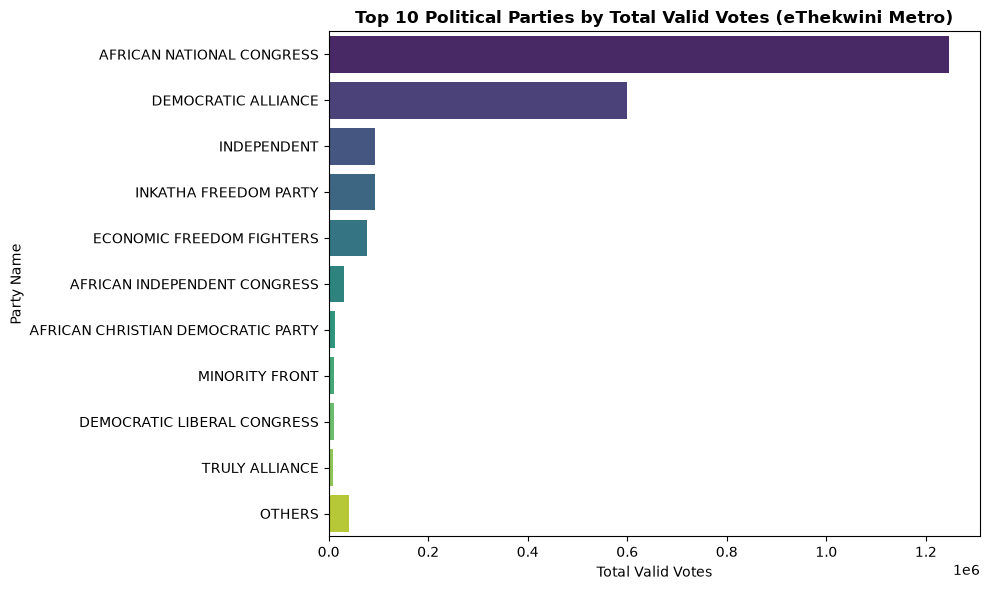

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv('National.csv')

# 2. Filter for your chosen municipality (e.g., eThekwini Metro)
metro_df = df[df['Municipality'] == 'ETH - eThekwini']

# 3. Aggregate votes by party
party_votes = metro_df.groupby('PartyName')['TotalValidVotes'].sum().reset_index()

# 4. Extract Top 10 parties and group the rest as 'OTHERS'
top_10 = party_votes.sort_values(by='TotalValidVotes', ascending=False).head(10)
others_sum = party_votes.sort_values(by='TotalValidVotes', ascending=False).iloc[10:]['TotalValidVotes'].sum()

plot_data = pd.concat([top_10, pd.DataFrame([{'PartyName': 'OTHERS', 'TotalValidVotes': others_sum}])], ignore_index=True)

# 5. Plot clean horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='TotalValidVotes', y='PartyName', palette='viridis')

plt.title('Top 10 Political Parties by Total Valid Votes (eThekwini Metro)', fontsize=12, fontweight='bold')
plt.xlabel('Total Valid Votes', fontsize=10)
plt.ylabel('Party Name', fontsize=10)
plt.tight_layout()

plt.show()

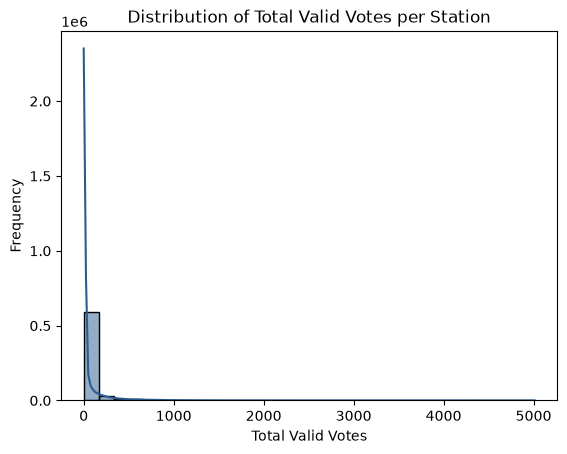

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['TotalValidVotes'], bins=30, kde=True, color='#2b5c8f')
plt.title('Distribution of Total Valid Votes per Station')
plt.xlabel('Total Valid Votes')
plt.ylabel('Frequency')
plt.show()

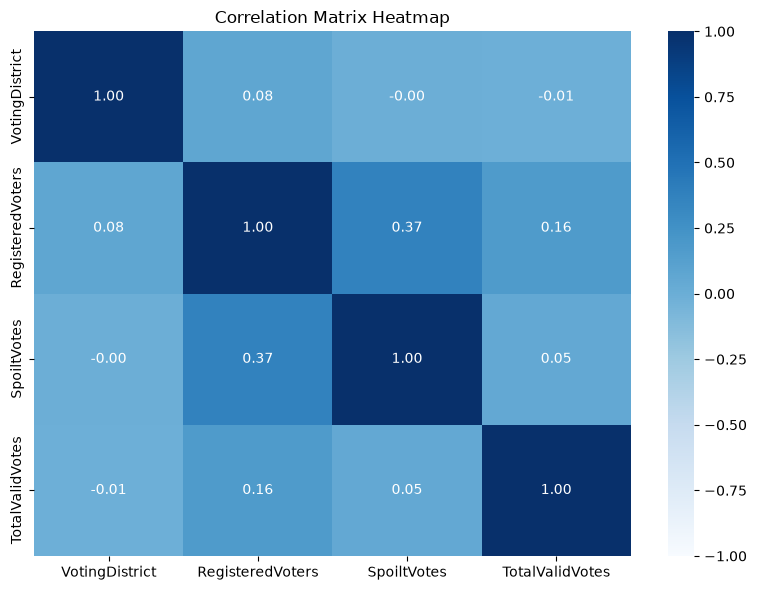

In [63]:
#here i compared numeric value columns only 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('National.csv')

# 1. Compute correlation matrix for numeric columns
corr = df.corr(numeric_only=True)

# 2. Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', vmin=-1, vmax=1)

# Formatting
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

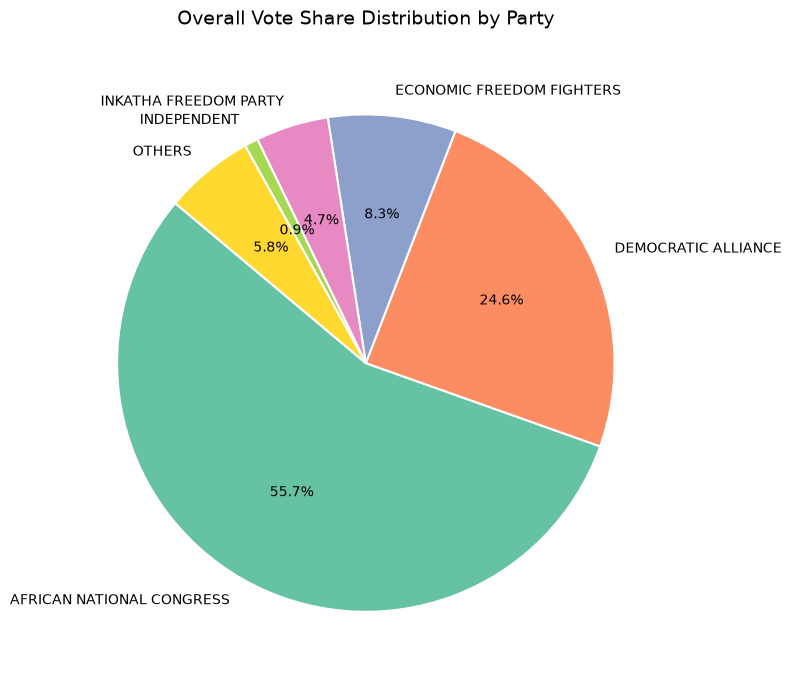

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv('National.csv')

# 2. Aggregate total valid votes by political party
party_votes = df.groupby('PartyName')['TotalValidVotes'].sum().sort_values(ascending=False)

# 3. Take top 5 parties and group remaining into 'OTHERS'
top_n = 5
top_parties = party_votes.head(top_n)
others = pd.Series({'OTHERS': party_votes.iloc[top_n:].sum()})
pie_data = pd.concat([top_parties, others])

# 4. Generate Pie Chart
plt.figure(figsize=(8, 8))
colors = sns.color_palette('Set2', len(pie_data))

plt.pie(
    pie_data, 
    labels=pie_data.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Overall Vote Share Distribution by Party', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

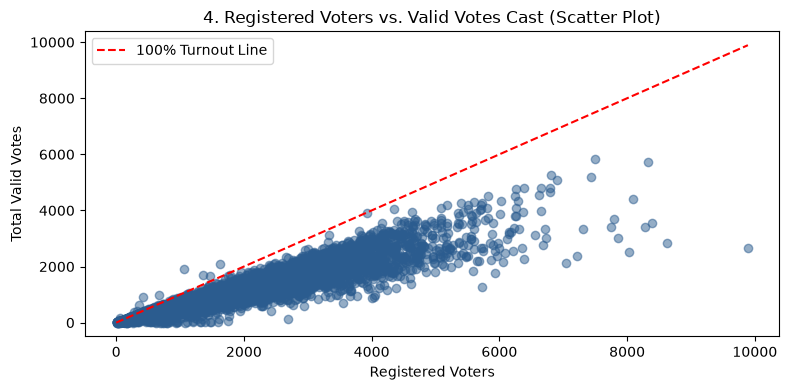

In [65]:
# Aggregate votes by station for PR ballots
station_df = df[df['BallotType'] == 'PR'].groupby('VotingDistrict').agg(
    RegVoters=('RegisteredVoters', 'max'),
    ValidVotes=('TotalValidVotes', 'sum')
).reset_index()

plt.figure(figsize=(8, 4))
plt.scatter(station_df['RegVoters'], station_df['ValidVotes'], alpha=0.5, color='#2b5c8f')
plt.plot([0, station_df['RegVoters'].max()], [0, station_df['RegVoters'].max()], 'r--', label='100% Turnout Line')
plt.title('4. Registered Voters vs. Valid Votes Cast (Scatter Plot)')
plt.xlabel('Registered Voters')
plt.ylabel('Total Valid Votes')
plt.legend()
plt.tight_layout()
plt.show()

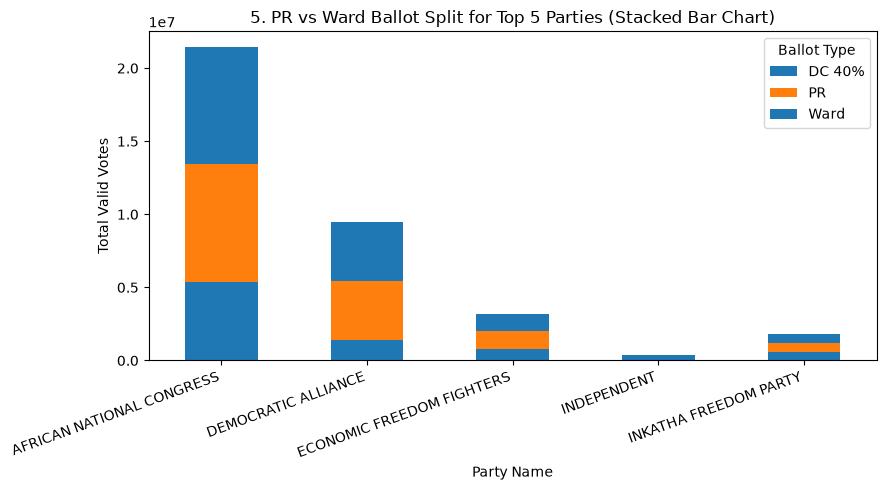

In [66]:
top5_parties = df.groupby('PartyName')['TotalValidVotes'].sum().nlargest(5).index
ballot_df = df[df['PartyName'].isin(top5_parties)].groupby(['PartyName', 'BallotType'])['TotalValidVotes'].sum().unstack()

ballot_df.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], figsize=(9, 5))
plt.title('5. PR vs Ward Ballot Split for Top 5 Parties (Stacked Bar Chart)')
plt.xlabel('Party Name')
plt.ylabel('Total Valid Votes')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Ballot Type')
plt.tight_layout()
plt.show()

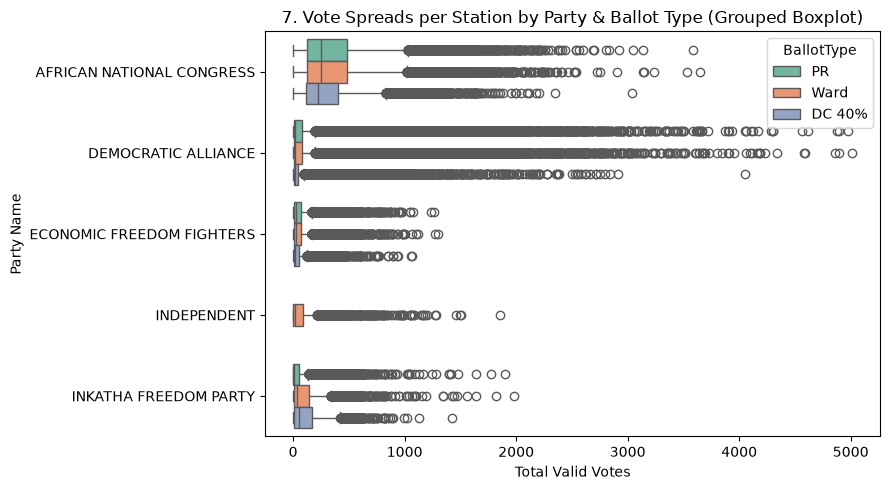

In [67]:
#Vote Spreads by Party & Ballot Type (Multivariate - Grouped Boxplot)
top5_df = df[df['PartyName'].isin(top5_parties)]

plt.figure(figsize=(9, 5))
sns.boxplot(data=top5_df, x='TotalValidVotes', y='PartyName', hue='BallotType', palette='Set2')
plt.title('7. Vote Spreads per Station by Party & Ballot Type (Grouped Boxplot)')
plt.xlabel('Total Valid Votes')
plt.ylabel('Party Name')
plt.tight_layout()
plt.show()

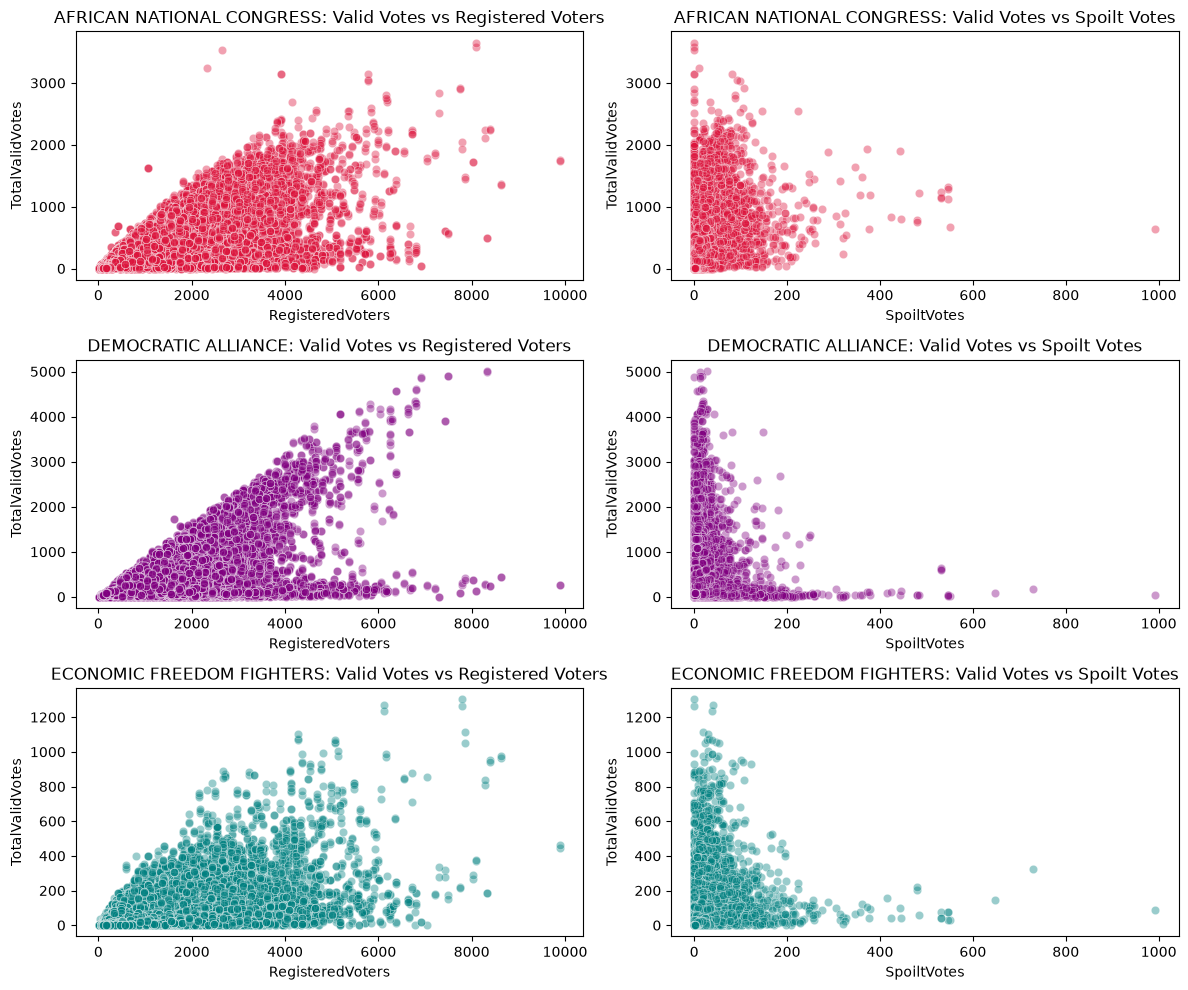

In [69]:
top3_parties = df.groupby('PartyName')['TotalValidVotes'].sum().nlargest(3).index

fig, axes = plt.subplots(len(top3_parties), 2, figsize=(12, 10))
colors = ['crimson', 'purple', 'teal']

for i, party in enumerate(top3_parties):
    sub_df = df[df['PartyName'] == party]
    
    # Registered Voters vs Total Valid Votes
    sns.scatterplot(data=sub_df, x='RegisteredVoters', y='TotalValidVotes', ax=axes[i, 0], alpha=0.4, color=colors[i])
    axes[i, 0].set_title(f'{party}: Valid Votes vs Registered Voters')
    
    # Spoilt Votes vs Total Valid Votes
    sns.scatterplot(data=sub_df, x='SpoiltVotes', y='TotalValidVotes', ax=axes[i, 1], alpha=0.4, color=colors[i])
    axes[i, 1].set_title(f'{party}: Valid Votes vs Spoilt Votes')

plt.tight_layout()
plt.show()

## **Stage 4: Point-in-Time Model — Build & Baseline**

In [80]:
y = df['WinningParty']

In [75]:
# Create total votes for each party in each ward

ward_party = (
    df.groupby(
        ['Province', 'Municipality', 'Ward', 'PartyName'],
        as_index=False
    )['TotalValidVotes']
    .sum()
)

# Find the highest vote total in each ward

ward_party['MaxVotes'] = (
    ward_party.groupby(
        ['Province', 'Municipality', 'Ward']
    )['TotalValidVotes']
    .transform('max')
)

# Select the party/parties with the highest votes

winners = ward_party[
    ward_party['TotalValidVotes'] == ward_party['MaxVotes']
].copy()

# Count winners in each ward

winner_count = (
    winners.groupby(
        ['Province', 'Municipality', 'Ward']
    )['PartyName']
    .transform('count')
)

# Create WinningParty

winners['WinningParty'] = winners['PartyName']

winners.loc[
    winner_count > 1,
    'WinningParty'
] = 'TIE'

# Keep one winner per ward

winning_party = (
    winners.groupby(
        ['Province', 'Municipality', 'Ward'],
        as_index=False
    )['WinningParty']
    .first()
)

# Remove old column if it exists

df = df.drop(columns=['WinningParty'], errors='ignore')

# Add WinningParty to df

df = df.merge(
    winning_party,
    on=['Province', 'Municipality', 'Ward'],
    how='left'
)

print("WinningParty created successfully.")
print(df['WinningParty'].value_counts())

WinningParty created successfully.
WinningParty
AFRICAN NATIONAL CONGRESS                         518163
DEMOCRATIC ALLIANCE                               114510
INKATHA FREEDOM PARTY                              17904
BUSHBUCKRIDGE RESIDENTS ASSOCIATION                  956
ECONOMIC FREEDOM FIGHTERS                            850
UNITED DEMOCRATIC MOVEMENT                           360
INDEPENDENT CIVIC ORGANISATION OF SOUTH AFRICA       139
CIVIC WARRIORS OF MARULENG                           124
KAROO GEMEENSKAP PARTY                                57
Name: count, dtype: int64


In [77]:
print(df.columns.tolist())

['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated', 'WinningParty']


In [81]:
features = [
    'Province',
    'Municipality',
    'Ward',
    'VotingDistrict',
    'VotingStationName',
    'RegisteredVoters',
    'BallotType',
    'SpoiltVotes',
    'DateGenerated'
]

In [82]:
X = df[features]
y = df['WinningParty']

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# 1. FEATURES
# -----------------------------

features = [
    'Province',
    'Municipality',
    'Ward',
    'VotingDistrict',
    'VotingStationName',
    'RegisteredVoters',
    'BallotType',
    'SpoiltVotes',
    'DateGenerated'
]

X = df[features]

# -----------------------------
# 2. TARGET
# -----------------------------

y = df['WinningParty']

# Encode target party names
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target classes:")
print(label_encoder.classes_)

# -----------------------------
# 3. DEFINE FEATURE TYPES
# -----------------------------

categorical_features = [
    'Province',
    'Municipality',
    'Ward',
    'VotingDistrict',
    'VotingStationName',
    'BallotType',
    'DateGenerated'
]

numerical_features = [
    'RegisteredVoters',
    'SpoiltVotes'
]

# -----------------------------
# 4. ENCODE CATEGORICAL FEATURES
# -----------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

# -----------------------------
# 5. RANDOM FOREST
# -----------------------------

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# 6. CREATE PIPELINE
# -----------------------------

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('random_forest', rf_model)
    ]
)

# -----------------------------
# 7. TRAIN / TEST SPLIT
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

# -----------------------------
# 8. TRAIN MODEL
# -----------------------------

model.fit(X_train, y_train)

# -----------------------------
# 9. MAKE PREDICTIONS
# -----------------------------

y_pred = model.predict(X_test)

# -----------------------------
# 10. ACCURACY
# -----------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nRandom Forest Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

# -----------------------------
# 11. CLASSIFICATION REPORT
# -----------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        labels=range(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

# -----------------------------
# 12. CONFUSION MATRIX
# -----------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

Target classes:
['AFRICAN NATIONAL CONGRESS' 'BUSHBUCKRIDGE RESIDENTS ASSOCIATION'
 'CIVIC WARRIORS OF MARULENG' 'DEMOCRATIC ALLIANCE'
 'ECONOMIC FREEDOM FIGHTERS'
 'INDEPENDENT CIVIC ORGANISATION OF SOUTH AFRICA' 'INKATHA FREEDOM PARTY'
 'KAROO GEMEENSKAP PARTY' 'UNITED DEMOCRATIC MOVEMENT']
Training records: 522450
Testing records: 130613

Random Forest Accuracy: 0.7934355692006155
Accuracy Percentage: 79.34355692006156

Classification Report:
                                                precision    recall  f1-score   support

                     AFRICAN NATIONAL CONGRESS       0.79      1.00      0.88    103633
           BUSHBUCKRIDGE RESIDENTS ASSOCIATION       0.00      0.00      0.00       191
                    CIVIC WARRIORS OF MARULENG       0.00      0.00      0.00        25
                           DEMOCRATIC ALLIANCE       0.00      0.00      0.00     22902
                     ECONOMIC FREEDOM FIGHTERS       0.00      0.00      0.00       170
INDEPENDENT CIVIC ORG

In [84]:
from sklearn.model_selection import cross_val_score

# Perform 5-Fold Cross-Validation
cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

# Display stability metrics
print("--- 5-Fold Cross-Validation Stability Results ---")

print("Accuracy Scores for each fold:")
print(cv_scores)

print(f"\nMean Cross-Validation Accuracy: {cv_scores.mean():.4f}")
print(f"Mean Accuracy Percentage: {cv_scores.mean() * 100:.2f}%")

print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"Stability: ± {cv_scores.std() * 100:.2f}%")

--- 5-Fold Cross-Validation Stability Results ---
Accuracy Scores for each fold:
[0.79343478 0.79343478 0.79343478 0.79343478 0.79343478]

Mean Cross-Validation Accuracy: 0.7934
Mean Accuracy Percentage: 79.34%
Standard Deviation: 0.0000
Stability: ± 0.00%


## **Stage 5: overfiting**

In [98]:
# Compare training accuracy vs. mean cross-validation accuracy

from sklearn.metrics import accuracy_score

# Training predictions
y_train_pred = model.predict(X_train)

# Training accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)

# Mean cross-validation accuracy
mean_cv_accuracy = cv_scores.mean()

# Calculate the gap
accuracy_gap = train_accuracy - mean_cv_accuracy

print("--- Training vs Cross-Validation Accuracy ---")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Mean CV Accuracy: {mean_cv_accuracy:.4f}")
print(f"Accuracy Gap: {accuracy_gap:.4f}")

--- Training vs Cross-Validation Accuracy ---
Training Accuracy: 0.7934
Mean CV Accuracy: 0.7934
Accuracy Gap: 0.0000


#create focusting model

In [100]:

import pandas as pd
import numpy as np

# Make sure DateGenerated is a datetime
df['DateGenerated'] = pd.to_datetime(
    df['DateGenerated'],
    errors='coerce'
)

# Remove rows where the date is missing
forecast_df = df.dropna(
    subset=['DateGenerated', 'TotalValidVotes']
).copy()

# Sort by date
forecast_df = forecast_df.sort_values('DateGenerated')

# Group total valid votes by date
daily_votes = (
    forecast_df
    .groupby('DateGenerated')['TotalValidVotes']
    .sum()
    .reset_index()
)

print(daily_votes.head())
print("\nNumber of dates:", len(daily_votes))

        DateGenerated  TotalValidVotes
0 2017-02-16 17:01:24         38517983

Number of dates: 1


## Stage 6: Persistence & Inference

In [96]:
import joblib

In [97]:
# Save the final trained Random Forest model
joblib.dump(rf_model, 'Voting.pkl')

print("Final model saved successfully.")

Final model saved successfully.
